# EDA - Exploratory Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("../data/ML/Predictive_Dataset.csv", parse_dates=["timestamp"])

df.head()

,timestamp,machine_id,temperature,vibration,pressure,load,ambient_temperature,is_running,produced_units,defective_units,...,rolling_vibration_std_24h,rolling_pressure_mean_24h,rolling_pressure_std_24h,running_ratio_24h,hours_since_last_failure,failure_count_last_7d,failure_count_last_30d,target_failure_72h,target_failure_type,target_RUL_hours
0,2022-01-01 00:00:00,1,49.3,2.28,4.61,89.27,17.8,1,120,2,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1617.0
1,2022-01-01 01:00:00,1,50.9,2.02,5.23,73.30,19.3,1,116,0,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1616.0
2,2022-01-01 02:00:00,1,48.2,1.80,5.25,86.79,18.6,1,117,1,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1615.0
3,2022-01-01 03:00:00,1,49.8,2.65,4.92,69.77,18.9,1,116,2,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1614.0
4,2022-01-01 04:00:00,1,46.3,2.20,5.15,84.98,17.9,1,115,0,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1613.0


In [2]:
# Soubor obsahuje 315 372 záznamů a 27 sloupců
df.shape

(315372, 27)

In [3]:
df.columns

Index(['timestamp', 'machine_id', 'temperature', 'vibration', 'pressure',
       'load', 'ambient_temperature', 'is_running', 'produced_units',
       'defective_units', 'operating_hours_since_maintenance',
       'machine_age_hours', 'health_index', 'health_delta_24h',
       'rolling_temp_mean_24h', 'rolling_temp_std_24h',
       'rolling_vibration_mean_24h', 'rolling_vibration_std_24h',
       'rolling_pressure_mean_24h', 'rolling_pressure_std_24h',
       'running_ratio_24h', 'hours_since_last_failure',
       'failure_count_last_7d', 'failure_count_last_30d', 'target_failure_72h',
       'target_failure_type', 'target_RUL_hours'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 315372 entries, 0 to 315371
Data columns (total 27 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   timestamp                          315372 non-null  datetime64[us]
 1   machine_id                         315372 non-null  int64         
 2   temperature                        315372 non-null  float64       
 3   vibration                          315372 non-null  float64       
 4   pressure                           315372 non-null  float64       
 5   load                               315372 non-null  float64       
 6   ambient_temperature                315372 non-null  float64       
 7   is_running                         315372 non-null  int64         
 8   produced_units                     315372 non-null  int64         
 9   defective_units                    315372 non-null  int64         
 10  operating_hours_since_maintenan

In [5]:
# Počet chybějících hodnot dle sloupců
df.isnull().sum()

timestamp                                 0
machine_id                                0
temperature                               0
vibration                                 0
pressure                                  0
load                                      0
ambient_temperature                       0
is_running                                0
produced_units                            0
defective_units                           0
operating_hours_since_maintenance         0
machine_age_hours                         0
health_index                              0
health_delta_24h                        288
rolling_temp_mean_24h                   276
rolling_temp_std_24h                    276
rolling_vibration_mean_24h              276
rolling_vibration_std_24h               276
rolling_pressure_mean_24h               276
rolling_pressure_std_24h                276
running_ratio_24h                       276
hours_since_last_failure              15939
failure_count_last_7d           

In [32]:
summary = pd.DataFrame({
    "sloupec": df.columns,
    "Datový typ": df.dtypes.astype(str).values,
    "Počet NaN hodnot": df.isnull().sum()
})


summary

,sloupec,Datový typ,Počet NaN hodnot
timestamp,timestamp,datetime64[us],0
machine_id,machine_id,int64,0
temperature,temperature,float64,0
vibration,vibration,float64,0
pressure,pressure,float64,0
load,load,float64,0
ambient_temperature,ambient_temperature,float64,0
is_running,is_running,int64,0
produced_units,produced_units,int64,0
defective_units,defective_units,int64,0


In [6]:
df.describe()

,timestamp,machine_id,temperature,vibration,pressure,load,ambient_temperature,is_running,produced_units,defective_units,...,rolling_vibration_mean_24h,rolling_vibration_std_24h,rolling_pressure_mean_24h,rolling_pressure_std_24h,running_ratio_24h,hours_since_last_failure,failure_count_last_7d,failure_count_last_30d,target_failure_72h,target_RUL_hours
count,315372,315372.000000,315372.000000,315372.000000,315372.000000,315372.000000,315372.000000,315372.000000,315372.000000,315372.000000,...,315096.000000,315096.000000,315096.000000,315096.000000,315096.000000,299433.000000,315372.000000,315372.000000,315372.000000,310325.000000
mean,2023-07-02 12:00:00,6.500000,66.109442,3.637951,5.656163,74.986429,22.999241,0.989774,91.731422,4.270290,...,3.638602,0.312202,5.656427,0.201881,0.989765,384.959547,0.231593,0.978048,0.099083,402.158389
min,2022-01-01 00:00:00,1.000000,43.800000,1.110000,4.350000,60.000000,15.400000,0.000000,0.000000,0.000000,...,1.942500,0.131595,4.985417,0.092215,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2022-10-01 18:00:00,3.750000,62.300000,3.240000,5.460000,67.550000,19.900000,1.000000,77.000000,3.000000,...,3.299583,0.268420,5.519167,0.178016,1.000000,173.000000,0.000000,1.000000,0.000000,178.000000
50%,2023-07-02 12:00:00,6.500000,66.300000,3.670000,5.660000,75.020000,23.000000,1.000000,91.000000,4.000000,...,3.687083,0.298867,5.677083,0.197350,1.000000,348.000000,0.000000,1.000000,0.000000,359.000000
75%,2024-04-01 06:00:00,9.250000,70.200000,4.060000,5.860000,82.420000,26.100000,1.000000,103.000000,5.000000,...,4.021250,0.331623,5.810417,0.218768,1.000000,559.000000,0.000000,1.000000,0.000000,578.000000
max,2024-12-31 00:00:00,12.000000,87.700000,6.100000,6.910000,90.000000,30.000000,1.000000,136.000000,11.000000,...,5.010000,1.432884,6.210417,0.605509,1.000000,1369.000000,1.000000,3.000000,1.000000,1818.000000
std,NaN,3.452058,5.777159,0.601211,0.288334,8.626285,3.283188,0.100606,22.086459,1.822713,...,0.508324,0.095550,0.205866,0.040298,0.055286,259.680602,0.421851,0.554888,0.298774,280.188659


In [7]:
# Distribuce target hodnoty predikce poruchy
df["target_failure_72h"].value_counts(normalize=True)

target_failure_72h
0    0.900917
1    0.099083
Name: proportion, dtype: float64

In [8]:
# Distribuce target hodnoty predikce typu poruchy
df["target_failure_type"].value_counts(normalize=True)


target_failure_type
mechanical     0.299539
overheating    0.269585
pressure       0.244240
electrical     0.186636
Name: proportion, dtype: float64

In [9]:
# Distribuce target hodnoty RUL
df["target_RUL_hours"].describe()

count    310325.000000
mean        402.158389
std         280.188659
min           0.000000
25%         178.000000
50%         359.000000
75%         578.000000
max        1818.000000
Name: target_RUL_hours, dtype: float64

In [10]:
# Korelace sloupců vůči target
df.corr(numeric_only=True)["target_failure_72h"].sort_values(ascending=False)

target_failure_72h                   1.000000
rolling_vibration_mean_24h           0.386467
rolling_pressure_mean_24h            0.381040
hours_since_last_failure             0.357313
vibration                            0.338122
operating_hours_since_maintenance    0.321496
rolling_temp_mean_24h                0.300787
temperature                          0.284182
pressure                             0.282313
defective_units                      0.259443
running_ratio_24h                    0.061425
machine_age_hours                    0.037997
is_running                           0.033709
produced_units                       0.013783
ambient_temperature                  0.005891
machine_id                           0.002435
load                                 0.001848
rolling_pressure_std_24h            -0.030369
rolling_vibration_std_24h           -0.050254
health_delta_24h                    -0.051783
rolling_temp_std_24h                -0.052700
failure_count_last_7d             

In [11]:
df.corr(numeric_only=True)["target_RUL_hours"].sort_values(ascending=False)

target_RUL_hours                     1.000000
health_index                         0.786960
failure_count_last_7d                0.403962
failure_count_last_30d               0.224066
health_delta_24h                     0.194379
rolling_vibration_std_24h            0.184972
rolling_temp_std_24h                 0.175686
rolling_pressure_std_24h             0.132683
load                                -0.003102
machine_id                          -0.014997
produced_units                      -0.018284
ambient_temperature                 -0.030556
is_running                          -0.072693
running_ratio_24h                   -0.187197
machine_age_hours                   -0.195173
target_failure_72h                  -0.436692
operating_hours_since_maintenance   -0.510853
defective_units                     -0.519474
pressure                            -0.569706
temperature                         -0.587850
rolling_temp_mean_24h               -0.601552
hours_since_last_failure          

In [12]:
#Časový rozsah dat
df["timestamp"].min(), df["timestamp"].max()

(Timestamp('2022-01-01 00:00:00'), Timestamp('2024-12-31 00:00:00'))

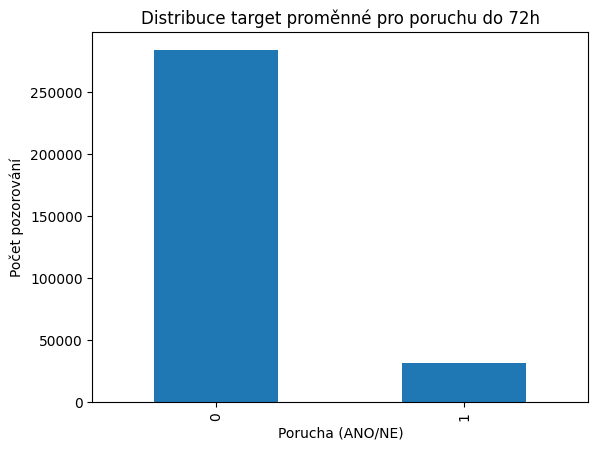

In [13]:
# GRAF - Distribuce taget proměnné pro predikci poruchy do 72 hodin.
df["target_failure_72h"].value_counts().plot(kind="bar")
plt.title("Distribuce target proměnné pro poruchu do 72h")
plt.xlabel("Porucha (ANO/NE)")
plt.ylabel("Počet pozorování")
plt.show()

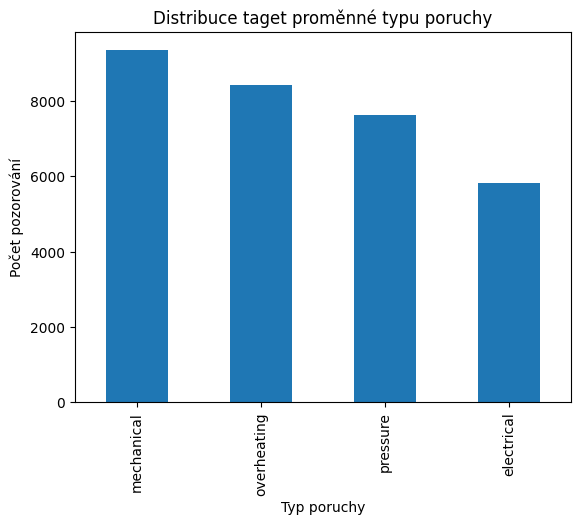

In [34]:
# GRAF - Distribuce taget proměnné pro predikci typu poruchy.
df["target_failure_type"].value_counts().plot(kind="bar")
plt.title("Distribuce taget proměnné typu poruchy")
plt.xlabel("Typ poruchy")
plt.ylabel("Počet pozorování")
plt.show()

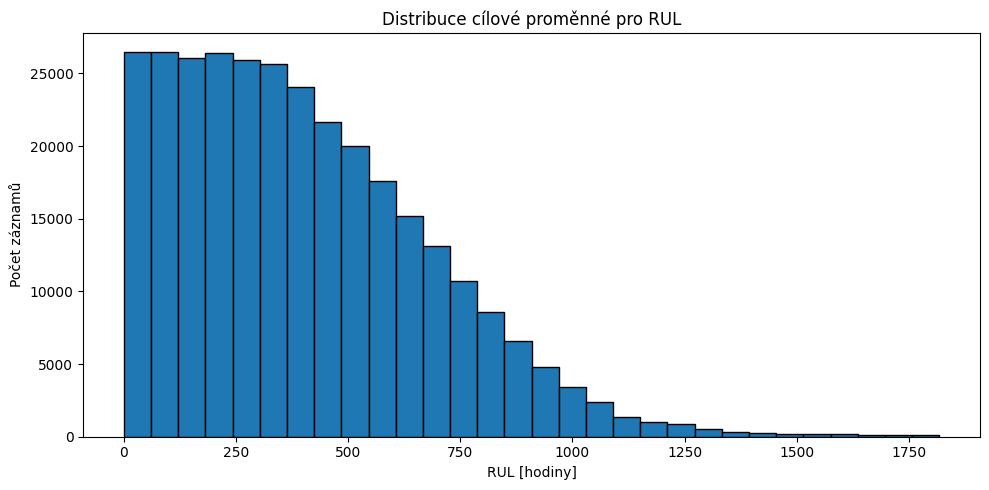

In [37]:
plt.figure(figsize=(10, 5))
plt.hist(df["target_RUL_hours"].dropna(), bins=30, edgecolor="black")
plt.title("Distribuce cílové proměnné pro RUL")
plt.xlabel("RUL [hodiny]")
plt.ylabel("Počet záznamů")
plt.tight_layout()
plt.show()



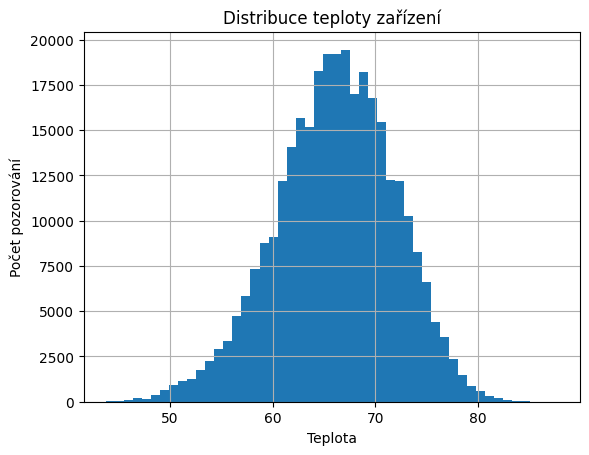

In [15]:
df["temperature"].hist(bins=50)
plt.title("Distribuce teploty zařízení")
plt.xlabel("Teplota")
plt.ylabel("Počet pozorování")
plt.show()


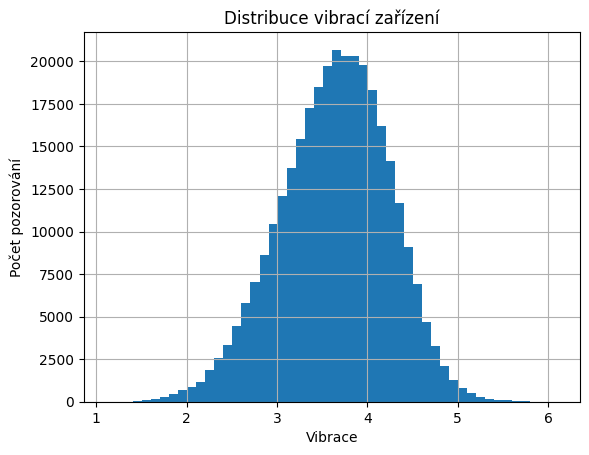

In [16]:
df["vibration"].hist(bins=50)
plt.title("Distribuce vibrací zařízení")
plt.xlabel("Vibrace")
plt.ylabel("Počet pozorování")
plt.show()

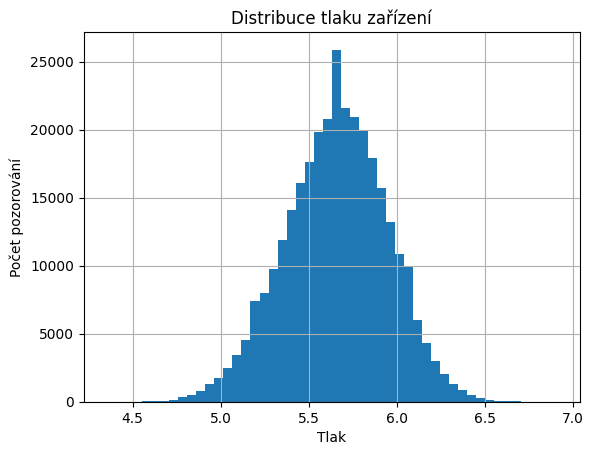

In [17]:
df["pressure"].hist(bins=50)
plt.title("Distribuce tlaku zařízení")
plt.xlabel("Tlak")
plt.ylabel("Počet pozorování")
plt.show()

In [18]:
df.groupby("target_failure_72h")["temperature"].mean()
# Stroje před poruchou mají vyšší teplotu

target_failure_72h
0    65.564981
1    71.059988
Name: temperature, dtype: float64

In [19]:
df.groupby("target_failure_72h")[["temperature","vibration","pressure"]].mean()

,temperature,vibration,pressure
target_failure_72h,,,
0,65.564981,3.570536,5.629168
1,71.059988,4.250925,5.901616
